# Experiment 1: Linear Regression with One Variable
### Objective:
Implement linear regression with one variable on the California Housing dataset to predict housing prices based on a single feature (`AveRooms` — the average number of rooms per dwelling).

### Tasks Covered:
1. Load and preprocess the dataset.
2. Implement linear regression using both **Gradient Descent (from scratch)** and the **Normal Equation**.
3. Evaluate the model performance using metrics such as Mean Squared Error (**MSE**) and **R-squared ($R^2$)**.
4. Visualize the fitted line along with the data points.

---
## Step 1: Data Ingestion & Preprocessing
We load the California Housing dataset using `sklearn.datasets`, extract our target feature array, and handle scale normalization using `StandardScaler` to help gradient descent converge efficiently.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Load the dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

#Extract feature (AveRooms) and target (MedHouseVal)
X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1, 1)

print("Dataset loaded successfully.")
print(f"Original Feature Matrix Shape (X): {X.shape}")
print(f"Original Target Vector Shape (y): {y.shape}\n")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}\n")

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)


X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)


m_train = len(y_train)
m_test = len(y_test)

X_b_train = np.c_[np.ones((m_train, 1)), X_train_scaled]
X_b_test = np.c_[np.ones((m_test, 1)), X_test_scaled]

print(f"Final Training Design Matrix Shape (X_b_train): {X_b_train.shape}")
print(f"Final Testing Design Matrix Shape (X_b_test): {X_b_test.shape}")

Dataset loaded successfully.
Original Feature Matrix Shape (X): (20640, 1)
Original Target Vector Shape (y): (20640, 1)

Training feature shape: (16512, 1)
Testing feature shape: (4128, 1)

Final Training Design Matrix Shape (X_b_train): (16512, 2)
Final Testing Design Matrix Shape (X_b_test): (4128, 2)


---
## Step 2: Model Implementation
Here we define both strategies to calculate the parameters:
1. **Normal Equation Analytical Solution**: $\theta = (X^T X)^{-1} X^T y$
2. **Batch Gradient Descent from Scratch**: Iterative parameter optimizations based on cost updates.

In [15]:
import numpy as np

# --- APPROACH A: Normal Equation ---
# Train using ONLY the training data
theta_normal_scaled = np.linalg.inv(X_b_train.T.dot(X_b_train)).dot(X_b_train.T).dot(y_train_scaled)

# Generate predictions using TEST data, then de-scale back to original units
y_pred_normal_scaled = X_b_test.dot(theta_normal_scaled)
y_pred_normal = scaler_y.inverse_transform(y_pred_normal_scaled)


# --- APPROACH B: Batch Gradient Descent from Scratch ---
def compute_cost(X, y, theta):
    """Compute Mean Squared Error Cost."""
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, theta, learning_rate, iterations):
    """Perform batch gradient descent to learn theta."""
    m = len(y)
    cost_history = []

    for i in range(iterations):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# Initialize hyperparameters
learning_rate = 0.01
iterations = 1500
initial_theta = np.zeros((2, 1))

# Run optimization loop ONLY on training data
theta_gd_scaled, cost_history = gradient_descent(X_b_train, y_train_scaled, initial_theta, learning_rate, iterations)

# Generate predictions using TEST data, then de-scale back to original units
y_pred_gd_scaled = X_b_test.dot(theta_gd_scaled)
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled)

print("Both models trained and test predictions generated successfully!")

Both models trained and test predictions generated successfully!


---
## Step 3: Performance Metric Evaluation
We unpack performance logs via Mean Squared Error (MSE) and $R^2$ scores across both calculated weights configurations to compare accuracy bounds.

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate metrics using the test ground truth (y_test) and unscaled predictions
mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("----- MODEL EVALUATION RESULTS (TEST SET) -----")
print(f"Normal Equation:\n  - Mean Squared Error (MSE): {mse_normal:.4f}\n  - R-squared (R²):           {r2_normal:.4f}")
print(f"Gradient Descent:\n  - Mean Squared Error (MSE): {mse_gd:.4f}\n  - R-squared (R²):           {r2_gd:.4f}\n")

print("----- MODEL WEIGHTS (SCALED SPACE) -----")
print(f"Normal Equation:  Intercept (theta_0) = {theta_normal_scaled[0][0]:.4f}, Slope (theta_1) = {theta_normal_scaled[1][0]:.4f}")
print(f"Gradient Descent: Intercept (theta_0) = {theta_gd_scaled[0][0]:.4f}, Slope (theta_1) = {theta_gd_scaled[1][0]:.4f}")

----- MODEL EVALUATION RESULTS (TEST SET) -----
Normal Equation:
  - Mean Squared Error (MSE): 1.2923
  - R-squared (R²):           0.0138
Gradient Descent:
  - Mean Squared Error (MSE): 1.2923
  - R-squared (R²):           0.0138

----- MODEL WEIGHTS (SCALED SPACE) -----
Normal Equation:  Intercept (theta_0) = 0.0000, Slope (theta_1) = 0.1585
Gradient Descent: Intercept (theta_0) = 0.0000, Slope (theta_1) = 0.1585


---
## Step 4: Visual Target Data Curves
We use `matplotlib` to render the fitted linear regression model curve plotted directly against actual data instances.

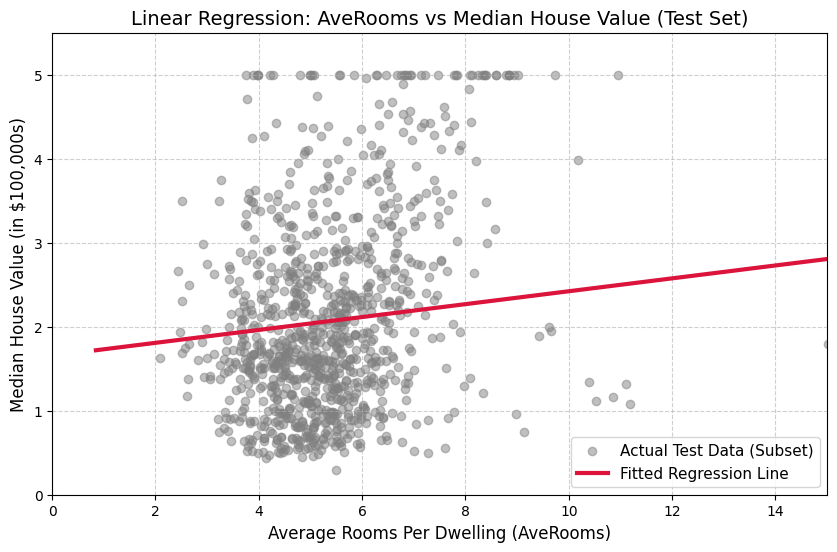

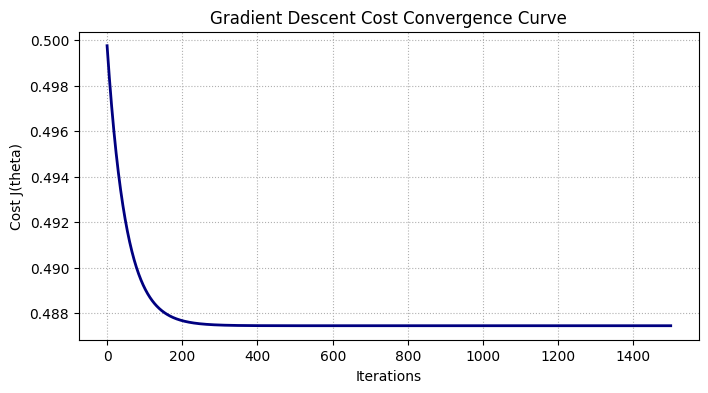

In [17]:
import matplotlib.pyplot as plt

# --- Plot 1: Regression Line vs Test Data ---
# Flatten X_test to 1D and get sorting indices based on test data for a smooth line plot
sort_axis = np.argsort(X_test.flatten())
X_test_sorted = X_test[sort_axis]
y_pred_gd_sorted = y_pred_gd[sort_axis]

plt.figure(figsize=(10, 6))
# Plot actual test data points (using up to the first 1000 points for clearer plotting visual)
plt.scatter(X_test[:1000], y_test[:1000], color='gray', alpha=0.5, label='Actual Test Data (Subset)')
# Plot the sorted regression line
plt.plot(X_test_sorted, y_pred_gd_sorted, color='crimson', linewidth=3, label='Fitted Regression Line')

plt.title('Linear Regression: AveRooms vs Median House Value (Test Set)', fontsize=14)
plt.xlabel('Average Rooms Per Dwelling (AveRooms)', fontsize=12)
plt.ylabel('Median House Value (in $100,000s)', fontsize=12)
plt.xlim(0, 15)
plt.ylim(0, 5.5)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- Plot 2: Convergence Curve History ---
plt.figure(figsize=(8, 4))
plt.plot(range(iterations), cost_history, color='navy', linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True, linestyle=':')
plt.show()

In [18]:
import numpy as np

# 1. Define the number of rooms you want to predict for
custom_rooms = 6.5  # Change this value to test different house sizes

# 2. Put the input into a 2D NumPy array (matching the shape the scaler expects)
custom_X = np.array([[custom_rooms]])

# 3. Scale the input using the already fitted scaler_X
custom_X_scaled = scaler_X.transform(custom_X)

# 4. Add the intercept term (prepend a 1) to match the model shape
custom_X_b = np.c_[np.ones((1, 1)), custom_X_scaled]

# 5. Predict using your trained weights (using Gradient Descent weights here)
# You can also use theta_normal_scaled if preferred
predicted_price_scaled = custom_X_b.dot(theta_gd_scaled)

# 6. De-scale the prediction back to original target units
predicted_price_original = scaler_y.inverse_transform(predicted_price_scaled)

# 7. Convert from California dataset units ($100,000s) to actual dollars
# The target variable is in units of $100,000 (e.g., 2.35 = $235,000)
actual_dollar_prediction = predicted_price_original[0][0] * 100000

print(f"--- CUSTOM HOUSE PRICE PREDICTION ---")
print(f"Input Average Rooms: {custom_rooms}")
print(f"Predicted Value (Dataset Units): {predicted_price_original[0][0]:.4f}")
print(f"Estimated Market Price: ${actual_dollar_prediction:,.2f}")

--- CUSTOM HOUSE PRICE PREDICTION ---
Input Average Rooms: 6.5
Predicted Value (Dataset Units): 2.1537
Estimated Market Price: $215,367.36
